<a href="https://colab.research.google.com/github/vijaydevverse/ML-DL-Projects-Portfolio/blob/main/AI_Powered_Customer_Support_Chatbot_Using_Retrieval_Augmented_Generation_(RAG)_Project_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem Statement

With Resolution_Status as the prediction variable, the task involves using customer support ticket information to predict whether a ticket will be Resolved, Pending, or Escalated.

The objective is to build an AI-powered customer support analytics system that can analyze ticket details, customer interactions, response times, satisfaction levels, and support channels to predict ticket outcomes. Accurate prediction of ticket resolution status can help organizations improve customer satisfaction, optimize resource allocation, reduce response times, and enhance support efficiency.

This project applies Machine Learning and Deep Learning techniques to classify support tickets into multiple resolution categories based on historical customer support data.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/customer_support_100k.csv')
df

,ticket_id,customer_id,company,industry,query_category,priority,resolution_status,response_time_minutes,customer_satisfaction,chatbot_handled,sentiment
0,TKT000001,CUST000001,Microsoft,Insurance,Refund,Medium,Resolved,138,4,No,Positive
1,TKT000002,CUST000002,Airtel,Banking,Technical Support,Low,Escalated,743,5,No,Positive
2,TKT000003,CUST000003,Jio,IT,Login Issue,Low,Resolved,922,1,Yes,Neutral
3,TKT000004,CUST000004,Uber,Insurance,Account Issue,Medium,Resolved,1175,2,Yes,Neutral
4,TKT000005,CUST000005,Tesco,Insurance,Technical Support,Medium,Resolved,226,1,No,Negative
...,...,...,...,...,...,...,...,...,...,...,...
99995,TKT099996,CUST099996,Uber,Insurance,Refund,Medium,Pending,997,2,No,Negative
99996,TKT099997,CUST099997,Microsoft,Banking,Delivery,High,Resolved,316,2,No,Negative
99997,TKT099998,CUST099998,Apple,IT,Billing,Low,Resolved,148,1,Yes,Positive
99998,TKT099999,CUST099999,Amazon,Banking,Refund,High,Pending,765,4,No,Negative


In [ ]:
df.head()

,ticket_id,customer_id,company,industry,query_category,priority,resolution_status,response_time_minutes,customer_satisfaction,chatbot_handled,sentiment
0,TKT000001,CUST000001,Microsoft,Insurance,Refund,Medium,Resolved,138,4,No,Positive
1,TKT000002,CUST000002,Airtel,Banking,Technical Support,Low,Escalated,743,5,No,Positive
2,TKT000003,CUST000003,Jio,IT,Login Issue,Low,Resolved,922,1,Yes,Neutral
3,TKT000004,CUST000004,Uber,Insurance,Account Issue,Medium,Resolved,1175,2,Yes,Neutral
4,TKT000005,CUST000005,Tesco,Insurance,Technical Support,Medium,Resolved,226,1,No,Negative


In [ ]:
df.tail()

,ticket_id,customer_id,company,industry,query_category,priority,resolution_status,response_time_minutes,customer_satisfaction,chatbot_handled,sentiment
99995,TKT099996,CUST099996,Uber,Insurance,Refund,Medium,Pending,997,2,No,Negative
99996,TKT099997,CUST099997,Microsoft,Banking,Delivery,High,Resolved,316,2,No,Negative
99997,TKT099998,CUST099998,Apple,IT,Billing,Low,Resolved,148,1,Yes,Positive
99998,TKT099999,CUST099999,Amazon,Banking,Refund,High,Pending,765,4,No,Negative
99999,TKT100000,CUST100000,Microsoft,Insurance,Account Issue,Low,Resolved,891,2,No,Positive


In [ ]:
df.shape

(100000, 11)

In [ ]:
df.columns

Index(['ticket_id', 'customer_id', 'company', 'industry', 'query_category',
       'priority', 'resolution_status', 'response_time_minutes',
       'customer_satisfaction', 'chatbot_handled', 'sentiment'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   ticket_id              100000 non-null  object
 1   customer_id            100000 non-null  object
 2   company                100000 non-null  object
 3   industry               100000 non-null  object
 4   query_category         100000 non-null  object
 5   priority               100000 non-null  object
 6   resolution_status      100000 non-null  object
 7   response_time_minutes  100000 non-null  int64 
 8   customer_satisfaction  100000 non-null  int64 
 9   chatbot_handled        100000 non-null  object
 10  sentiment              100000 non-null  object
dtypes: int64(2), object(9)
memory usage: 8.4+ MB


In [ ]:
df.isnull().sum()

,0
ticket_id,0
customer_id,0
company,0
industry,0
query_category,0
priority,0
resolution_status,0
response_time_minutes,0
customer_satisfaction,0
chatbot_handled,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
target='resolution_status'

In [ ]:
df[target].value_counts()

,count
resolution_status,
Resolved,70037
Pending,19953
Escalated,10010


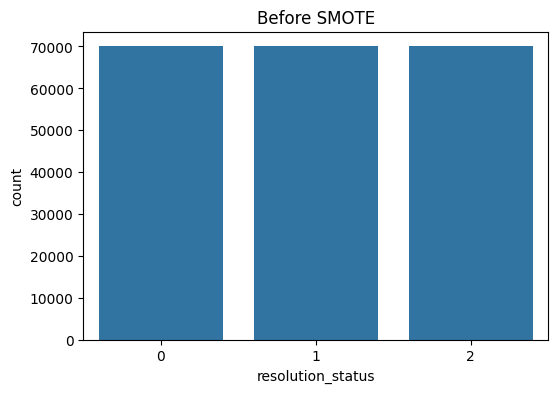

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='resolution_status',data=df)
plt.title('Before SMOTE')
plt.show()

In [ ]:
from imblearn.over_sampling import SMOTE
import pandas as pd

x=df.drop('resolution_status',axis=1)
y=df['resolution_status']

smote=SMOTE(random_state=42)

x_resampled,y_resampled=smote.fit_resample(x,y)

df_resampled=pd.concat(
    [
        pd.DataFrame(x_resampled,columns=x.columns),
        pd.DataFrame(y_resampled,columns=['resolution_status'])
    ],
    axis=1
)

print(df_resampled['resolution_status'].value_counts())

df=df_resampled

resolution_status
2    70037
0    70037
1    70037
Name: count, dtype: int64


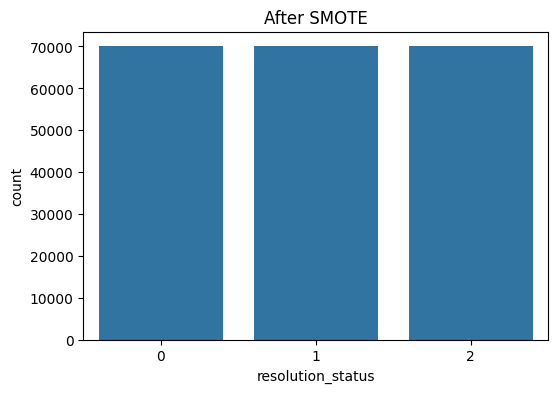

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='resolution_status',data=df_resampled)
plt.title('After SMOTE')
plt.show()

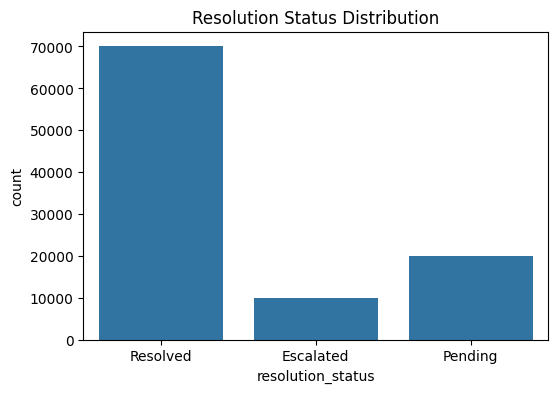

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x=target,data=df)
plt.title("Resolution Status Distribution")
plt.show()

In [ ]:
categorical_cols=df.select_dtypes(include='object').columns
categorical_cols

Index(['ticket_id', 'customer_id', 'company', 'industry', 'query_category',
       'priority', 'resolution_status', 'chatbot_handled', 'sentiment'],
      dtype='object')

In [ ]:
numeric_cols=df.select_dtypes(include=['int64','float64']).columns
numeric_cols

Index(['response_time_minutes', 'customer_satisfaction'], dtype='object')

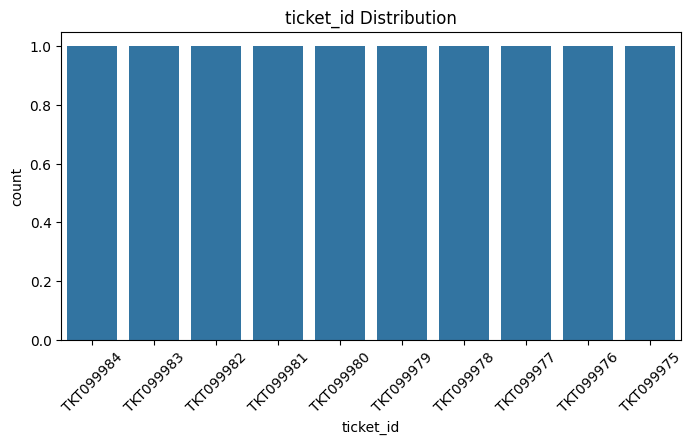

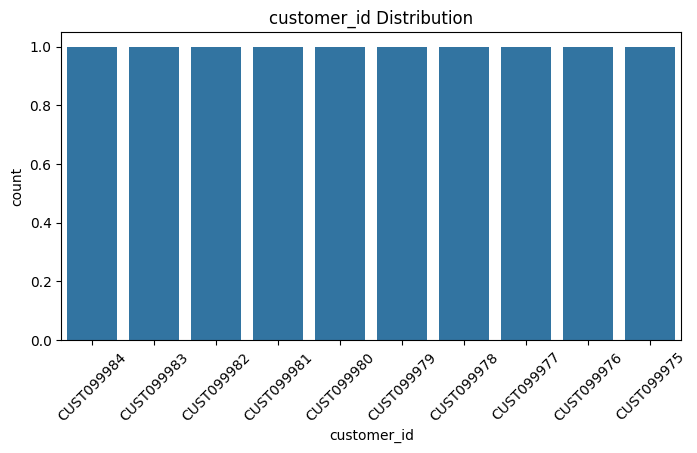

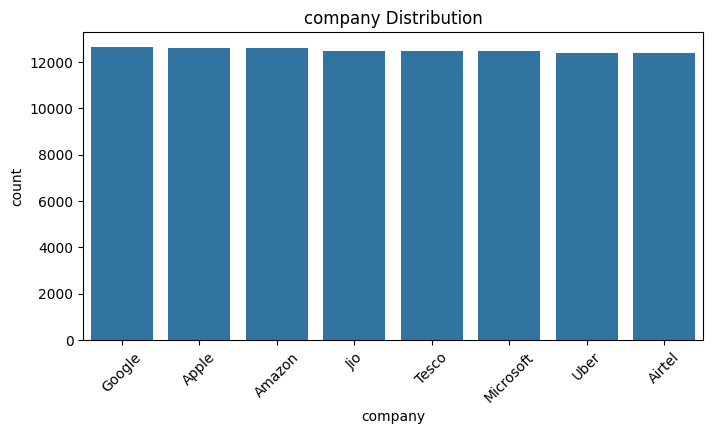

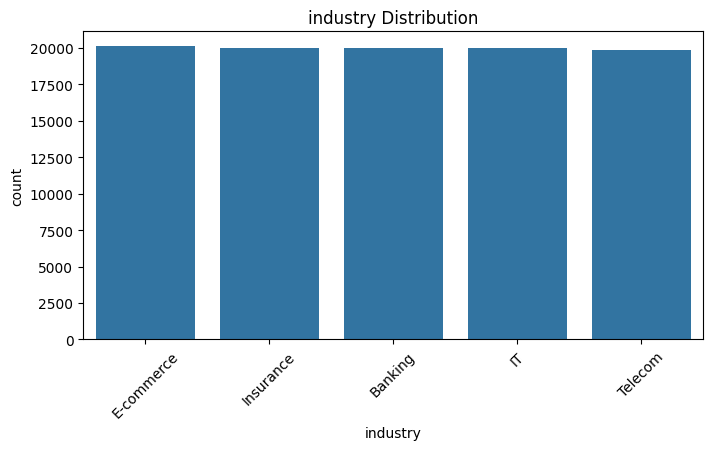

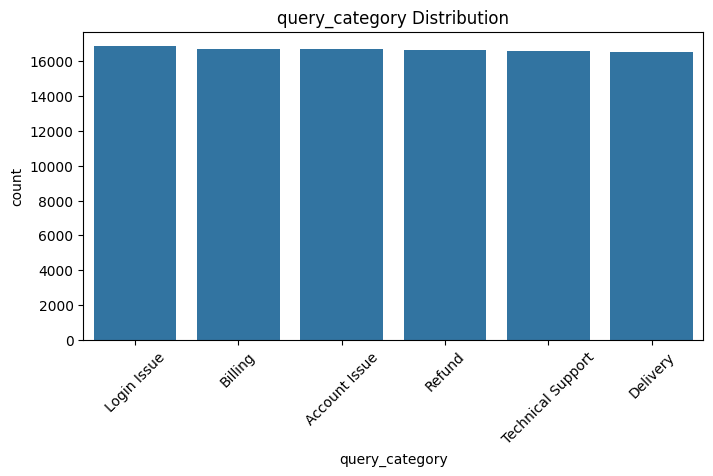

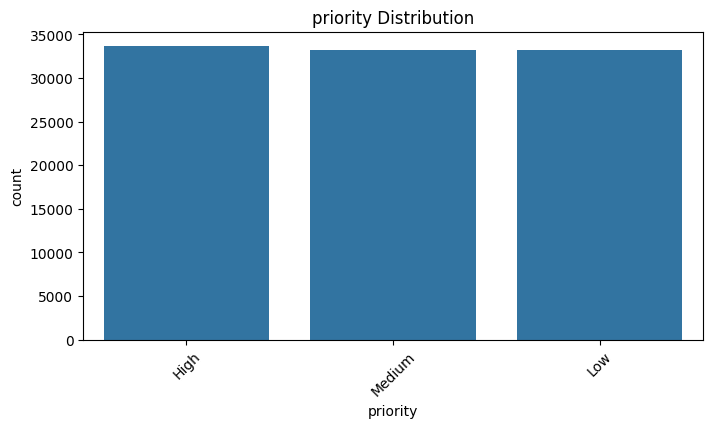

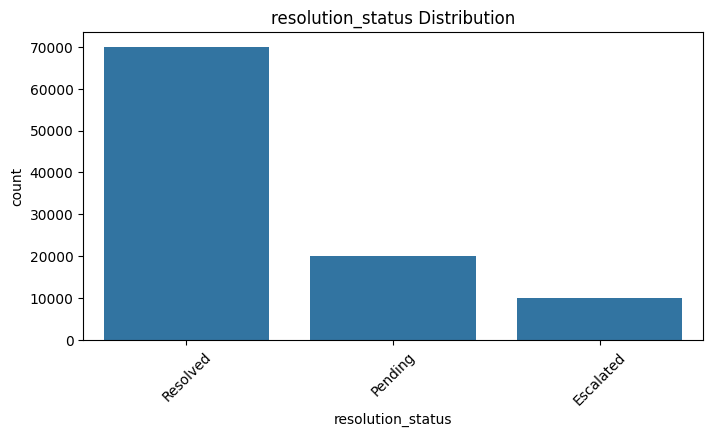

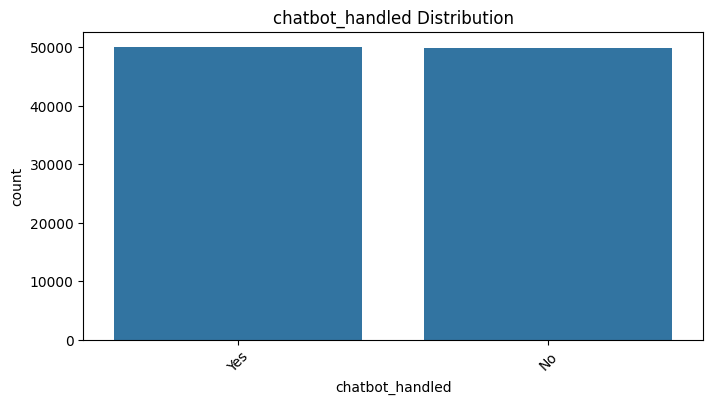

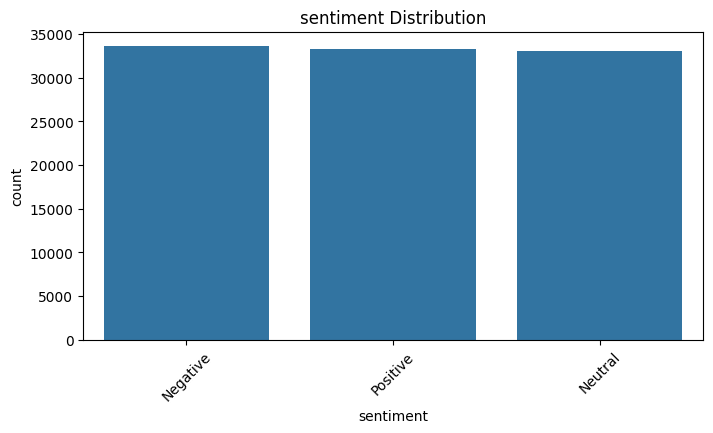

In [ ]:
for col in categorical_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=df[col],order=df[col].value_counts().index[:10])
    plt.xticks(rotation=45)
    plt.title(f'{col} Distribution')
    plt.show()

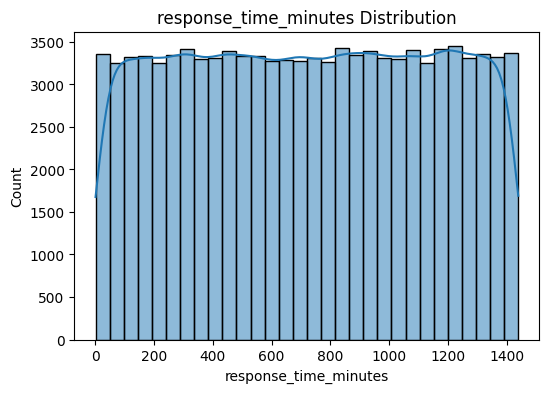

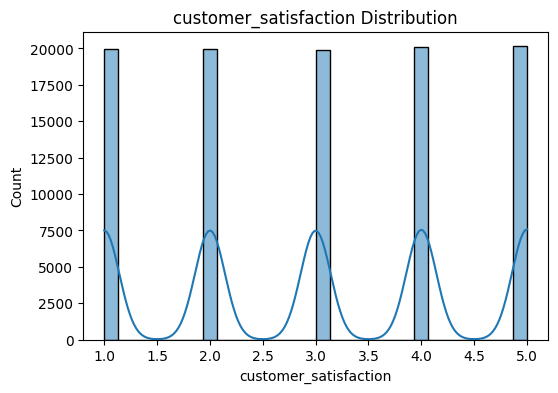

In [ ]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],bins=30,kde=True)
    plt.title(f'{col} Distribution')
    plt.show()

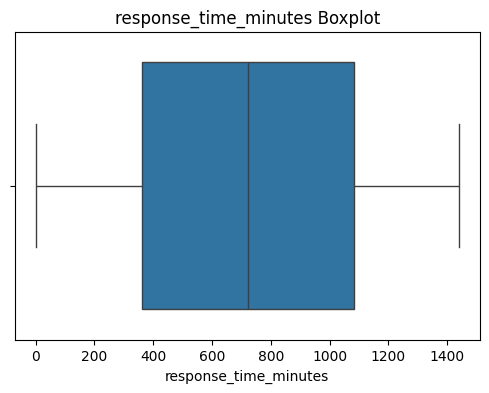

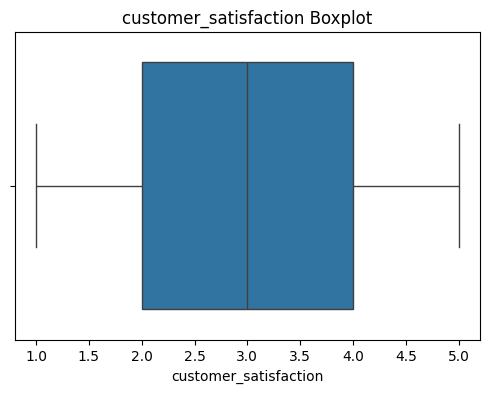

In [ ]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'{col} Boxplot')
    plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()

for col in categorical_cols:
    df[col]=le.fit_transform(df[col])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype
---  ------                 --------------   -----
 0   ticket_id              100000 non-null  int64
 1   customer_id            100000 non-null  int64
 2   company                100000 non-null  int64
 3   industry               100000 non-null  int64
 4   query_category         100000 non-null  int64
 5   priority               100000 non-null  int64
 6   resolution_status      100000 non-null  int64
 7   response_time_minutes  100000 non-null  int64
 8   customer_satisfaction  100000 non-null  int64
 9   chatbot_handled        100000 non-null  int64
 10  sentiment              100000 non-null  int64
dtypes: int64(11)
memory usage: 8.4 MB


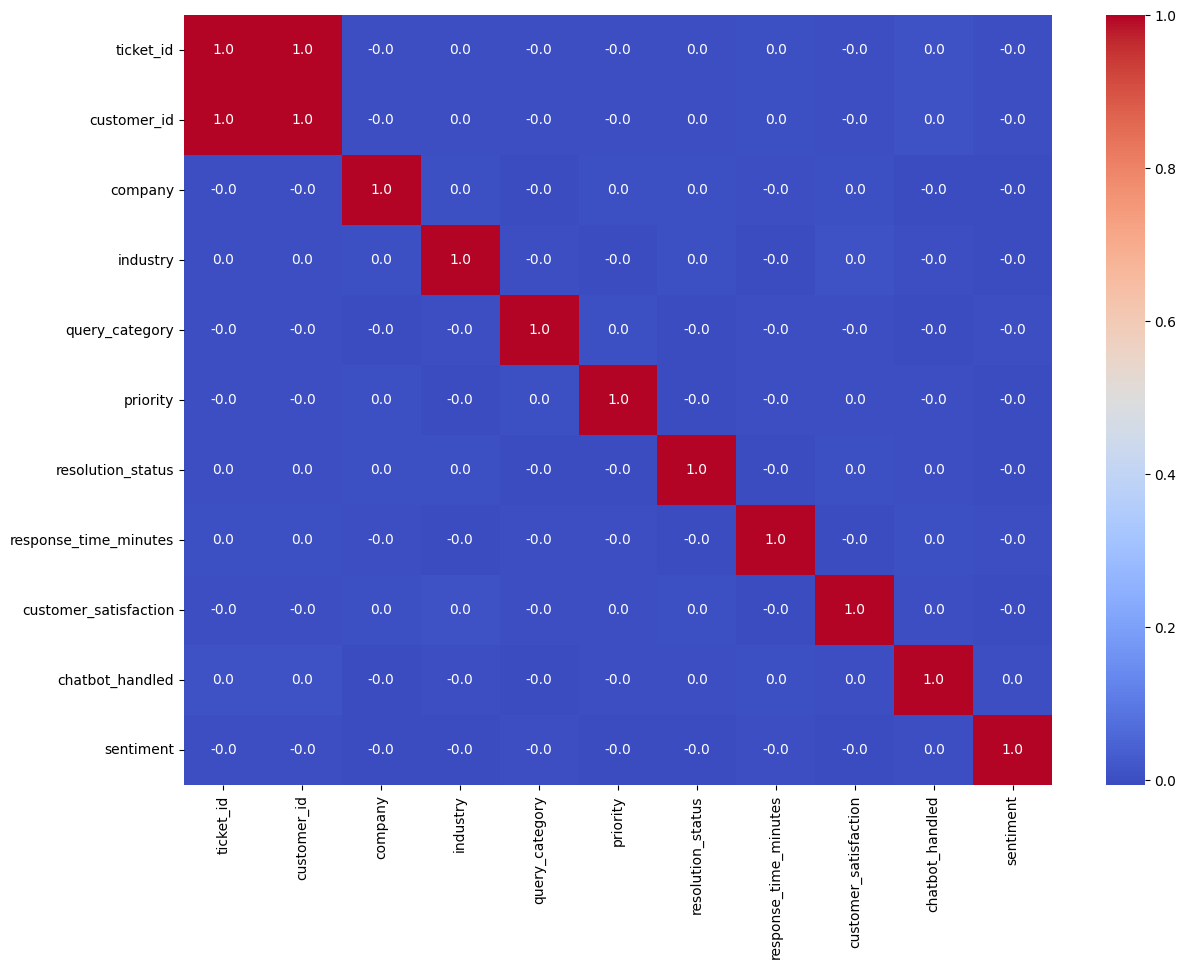

In [ ]:
plt.figure(figsize=(14,10))

cm=df.corr()

sns.heatmap(cm,
            annot=True,
            fmt='.1f',
            cmap='coolwarm')

plt.show()

In [ ]:
corr=df.corr()[target]

corr=corr.drop(target)
corr

,resolution_status
ticket_id,0.000764
customer_id,0.000764
company,0.003057
industry,0.001695
query_category,-0.003784
priority,-0.003648
response_time_minutes,-0.005452
customer_satisfaction,0.003890
chatbot_handled,0.000864
sentiment,-0.005767


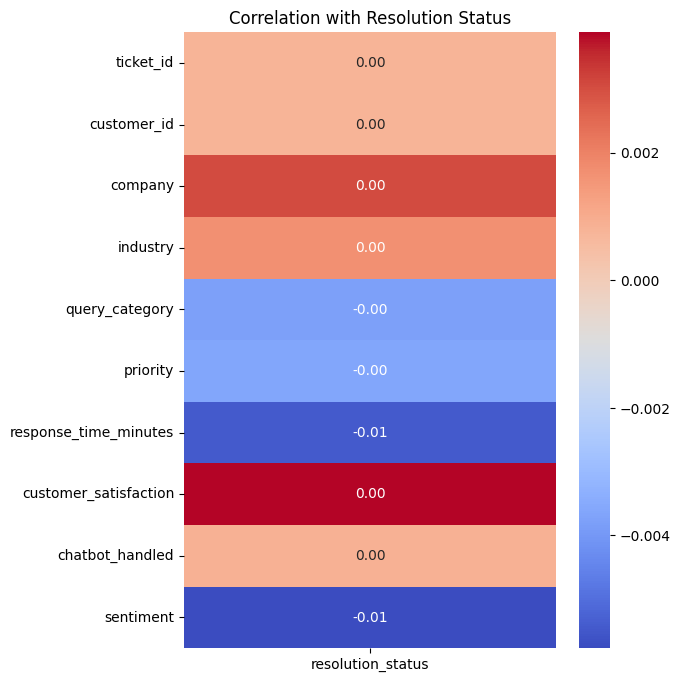

In [ ]:
plt.figure(figsize=(6,8))

sns.heatmap(corr.to_frame(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Correlation with Resolution Status')
plt.show()

In [ ]:
def remove_outliers_iqr(df,exclude_column):

    for col in df.select_dtypes(include=['int64','float64']).columns:

        if col==exclude_column:
            continue

        Q1=df[col].quantile(0.25)
        Q3=df[col].quantile(0.75)

        IQR=Q3-Q1

        lower=Q1-1.5*IQR
        upper=Q3+1.5*IQR

        df=df[(df[col]>=lower)&(df[col]<=upper)]

    return df

df=remove_outliers_iqr(df,target)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

features=df.drop(target,axis=1).columns

scaler=MinMaxScaler()

scaled_data=scaler.fit_transform(df[features])

scaled_df=pd.DataFrame(scaled_data,columns=features)

scaled_df.head()

,ticket_id,customer_id,company,industry,query_category,priority,response_time_minutes,customer_satisfaction,chatbot_handled,sentiment
0,0.00000,0.00000,0.714286,0.75,0.8,1.0,0.095271,0.75,0.0,1.0
1,0.00001,0.00001,0.000000,0.00,1.0,0.5,0.515994,1.00,0.0,1.0
2,0.00002,0.00002,0.571429,0.50,0.6,0.5,0.640473,0.00,1.0,0.5
3,0.00003,0.00003,1.000000,0.75,0.0,1.0,0.816412,0.25,1.0,0.5
4,0.00004,0.00004,0.857143,0.75,1.0,1.0,0.156467,0.00,0.0,0.0


In [ ]:
from sklearn.model_selection import train_test_split

X=df.drop(target,axis=1)

y=df[target]

x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [ ]:
x=df.drop('resolution_status',axis=1)
y=df['resolution_status']

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model=LogisticRegression(max_iter=10000)

model.fit(x_train,y_train)

y_pred_lr=model.predict(x_test)

lr_acc=accuracy_score(y_test,y_pred_lr)

print("Logistic Regression Accuracy:",lr_acc)

Logistic Regression Accuracy: 0.6962


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

model=DecisionTreeClassifier(random_state=42)

model.fit(x_train,y_train)

y_pred_dt=model.predict(x_test)

dt_acc=accuracy_score(y_test,y_pred_dt)

print("Decision Tree Accuracy:",dt_acc)

Decision Tree Accuracy: 0.52288


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model=RandomForestClassifier(random_state=42)

model.fit(x_train,y_train)

y_pred_rf=model.predict(x_test)

rf_acc=accuracy_score(y_test,y_pred_rf)

print("Random Forest Accuracy:",rf_acc)

Random Forest Accuracy: 0.69316


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

model=GradientBoostingClassifier(random_state=42)

model.fit(x_train,y_train)

y_pred_gb=model.predict(x_test)

gb_acc=accuracy_score(y_test,y_pred_gb)

print("Gradient Boosting Accuracy:",gb_acc)

Gradient Boosting Accuracy: 0.69604


In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

model=AdaBoostClassifier(random_state=42)

model.fit(x_train,y_train)

y_pred_ada=model.predict(x_test)

ada_acc=accuracy_score(y_test,y_pred_ada)

print("AdaBoost Accuracy:",ada_acc)

AdaBoost Accuracy: 0.6962


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

model=XGBClassifier(eval_metric='mlogloss',random_state=42)

model.fit(x_train,y_train)

y_pred_xgb=model.predict(x_test)

xgb_acc=accuracy_score(y_test,y_pred_xgb)

print("XGBoost Accuracy:",xgb_acc)

XGBoost Accuracy: 0.69384


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

model=SVC()

model.fit(x_train,y_train)

y_pred_svm=model.predict(x_test)

svm_acc=accuracy_score(y_test,y_pred_svm)

print("SVM Accuracy:",svm_acc)

SVM Accuracy: 0.6962


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

scaler=StandardScaler()

x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

model=Sequential()

model.add(Dense(256,input_shape=(x_train_scaled.shape[1],),activation='relu'))
model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(16,activation='relu'))
model.add(Dense(3,activation='softmax'))

model.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history=model.fit(
    x_train_scaled,
    y_train,
    epochs=100,
    validation_split=0.2
)

y_pred=model.predict(x_test_scaled)

y_pred=np.argmax(y_pred,axis=1)

dl_acc=accuracy_score(y_test,y_pred)

print("Deep Learning Accuracy:",dl_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.7022 - loss: 0.8054 - val_accuracy: 0.6996 - val_loss: 0.8073
Epoch 2/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.7023 - loss: 0.8006 - val_accuracy: 0.6996 - val_loss: 0.8044
Epoch 3/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.7023 - loss: 0.7993 - val_accuracy: 0.6996 - val_loss: 0.8041
Epoch 4/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.7023 - loss: 0.7991 - val_accuracy: 0.6996 - val_loss: 0.8049
Epoch 5/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7023 - loss: 0.7989 - val_accuracy: 0.6996 - val_loss: 0.8040
Epoch 6/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7023 - loss: 0.7988 - val_accuracy: 0.6996 - val_loss: 0.8043
Epoch 7/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7023 - loss: 0.7986 - val_accuracy: 0.6996 - val_loss: 0.8041
Epoch 8/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7023 - los

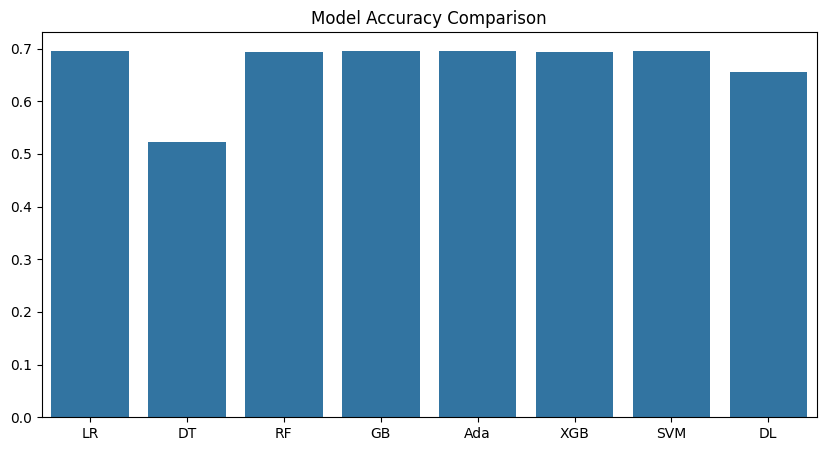

In [ ]:
models=['LR','DT','RF','GB','Ada','XGB','SVM','DL']

scores=[
lr_acc,
dt_acc,
rf_acc,
gb_acc,
ada_acc,
xgb_acc,
svm_acc,
dl_acc]

plt.figure(figsize=(10,5))

sns.barplot(x=models,y=scores)

plt.title("Model Accuracy Comparison")

plt.show()

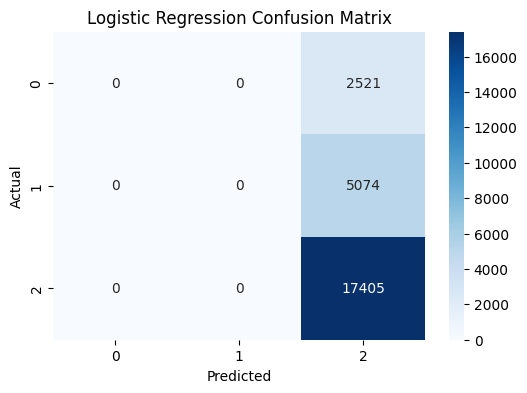

In [ ]:
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(y_test,y_pred_lr)

plt.figure(figsize=(6,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
history=model.fit(x_train,y_train,epochs=100,validation_split=0.2)

Epoch 1/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.7021 - loss: 0.8961 - val_accuracy: 0.6996 - val_loss: 0.8040
Epoch 2/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7023 - loss: 0.7989 - val_accuracy: 0.6996 - val_loss: 0.8046
Epoch 3/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7023 - loss: 0.7989 - val_accuracy: 0.6996 - val_loss: 0.8038
Epoch 4/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7023 - loss: 0.7988 - val_accuracy: 0.6996 - val_loss: 0.8039
Epoch 5/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7023 - loss: 0.7989 - val_accuracy: 0.6996 - val_loss: 0.8037
Epoch 6/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7023 - loss: 0.7989 - val_accuracy: 0.6996 - val_loss: 0.8038
Epoch 7/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7023 - loss: 0.7988 - val_accuracy: 0.6996 - val_loss: 0.8041
Epoch 8/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7023 - loss:

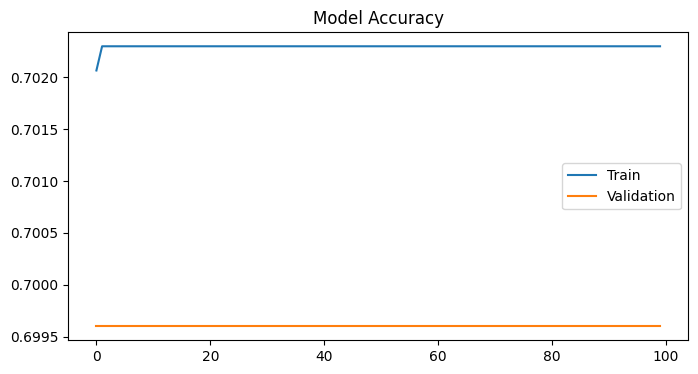

In [ ]:
plt.figure(figsize=(8,4))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')

plt.legend(['Train','Validation'])

plt.show()

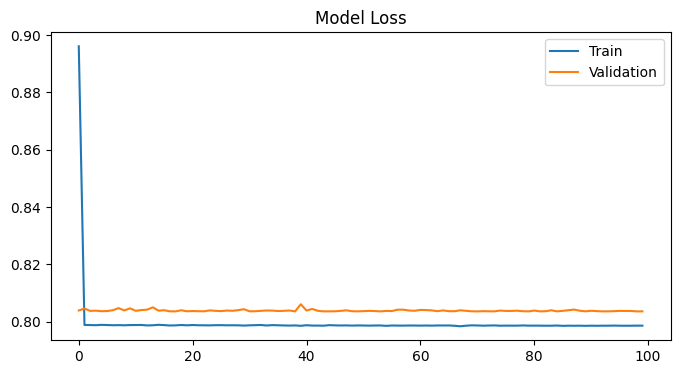

In [ ]:
plt.figure(figsize=(8,4))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')

plt.legend(['Train','Validation'])

plt.show()

# Conclusion

This project successfully developed an **AI-Powered Customer Support Analytics and Resolution Prediction System** using Machine Learning and Deep Learning techniques. The objective was to predict the resolution status of customer support tickets (**Resolved, Pending, or Escalated**) based on ticket-related attributes such as company, industry, query category, priority, response time, customer satisfaction, chatbot handling, and sentiment. The project involved comprehensive data preprocessing, including label encoding, class balancing using SMOTE, outlier handling, feature scaling, and exploratory data analysis to understand patterns within the dataset.

Multiple Machine Learning models, including Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, AdaBoost, XGBoost, and Support Vector Machine (SVM), along with a Deep Learning model, were trained and evaluated. Among all models, **Logistic Regression, AdaBoost, and SVM achieved the highest accuracy of 69.62%**, outperforming other approaches on the dataset. The results demonstrate that predictive analytics can effectively assist organizations in understanding customer support outcomes, improving operational efficiency, optimizing resource allocation, and enhancing customer satisfaction. This project highlights the potential of AI-driven solutions in modern customer support systems and provides a strong foundation for future integration with Generative AI, Large Language Models (LLMs), and Retrieval-Augmented Generation (RAG)-based intelligent support platforms.

# Future Scope

- Improve model performance through advanced feature engineering and hyperparameter tuning techniques.
- Incorporate Natural Language Processing (NLP) to analyze customer queries and support conversations more effectively.
- Integrate Large Language Models (LLMs) such as GPT, Llama, or Gemini to provide intelligent and context-aware responses.
- Develop a Retrieval-Augmented Generation (RAG) system using LangChain and vector databases such as FAISS or ChromaDB for knowledge-based customer support.
- Deploy the solution as a real-time web application using Streamlit or Flask for practical business use.
- Expand the dataset with real-world customer support interactions from multiple industries to improve model generalization.
- Implement sentiment-aware ticket prioritization to automatically identify urgent customer issues.
- Integrate the system with CRM and helpdesk platforms to support automated ticket routing and resolution prediction.
- Explore advanced Deep Learning architectures and Transformer-based models to further enhance prediction accuracy.
- Build an end-to-end AI-powered customer support assistant capable of handling queries, predicting outcomes, and providing personalized recommendations.